#### Sales Dashboard Project - Data Cleaning Notebook
#### Dataset: Superstore Sales Dataset
#### Tool: Python, Pandas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
superstore_df = pd.read_csv("superstore.csv")
print("Dataset Shape:", superstore_df.shape)
print("\nFirst 5 Rows:")
superstore_df.head()

Dataset Shape: (9994, 21)

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,9/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,9/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11/10/2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11/10/2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
print("Dataset Info:")
print(superstore_df.info())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quant

In [9]:
print("Statistical Summary:")
superstore_df.describe()

Statistical Summary:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
print("Missing Values:")
missing = superstore_df.isnull().sum()
missing_percent = (superstore_df.isnull().sum() / len(superstore_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])
print("\nTotal missing values:", superstore_df.isnull().sum().sum())

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

Total missing values: 0


In [12]:
duplicates = superstore_df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Remove duplicates
superstore_df = superstore_df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {superstore_df.shape}")

Total duplicate rows: 0
Dataset shape after removing duplicates: (9994, 21)


In [13]:
# Convert Order Date and Ship Date to proper datetime format
superstore_df['Order Date'] = pd.to_datetime(superstore_df['Order Date'], dayfirst=True, format='mixed')
superstore_df['Ship Date'] = pd.to_datetime(superstore_df['Ship Date'], dayfirst=True, format='mixed')

print("Date columns converted successfully!")
print(superstore_df[['Order Date', 'Ship Date']].dtypes)

Date columns converted successfully!
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [14]:
# Extract useful date features
superstore_df['Order Month'] = superstore_df['Order Date'].dt.month_name()
superstore_df['Order Year'] = superstore_df['Order Date'].dt.year
superstore_df['Order Quarter'] = superstore_df['Order Date'].dt.quarter

# Calculate shipping days
superstore_df['Ship Days'] = (superstore_df['Ship Date'] - superstore_df['Order Date']).dt.days

print("New columns created:")
print(superstore_df[['Order Date', 'Order Month', 'Order Year', 'Order Quarter', 'Ship Days']].head())

New columns created:
  Order Date Order Month  Order Year  Order Quarter  Ship Days
0 2013-11-09    November        2013              4          3
1 2013-11-09    November        2013              4          3
2 2013-06-13        June        2013              2          4
3 2012-10-11     October        2012              4          7
4 2012-10-11     October        2012              4          7


In [15]:
print("Column Data Types:")
print(superstore_df.dtypes)

Column Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Month                 str
Order Year                int32
Order Quarter             int32
Ship Days                 int64
dtype: object


In [16]:
print("Unique values per column:")
for col in ['Region', 'Category', 'Sub-Category', 'Segment', 'Ship Mode']:
    print(f"{col}: {superstore_df[col].unique()}")

Unique values per column:
Region: <ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Category: <ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Sub-Category: <ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str
Segment: <ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Ship Mode: <ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str


In [17]:
print("Rows with negative profit:")
negative_profit = superstore_df[superstore_df['Profit'] < 0]
print(f"Total rows with negative profit: {len(negative_profit)}")
print(f"Percentage: {len(negative_profit)/len(superstore_df)*100:.1f}%")

print("\nRows with negative sales:")
negative_sales = superstore_df[superstore_df['Sales'] < 0]
print(f"Total rows with negative sales: {len(negative_sales)}")

Rows with negative profit:
Total rows with negative profit: 1871
Percentage: 18.7%

Rows with negative sales:
Total rows with negative sales: 0


C:\Users\USER\AppData\Local\Temp\ipykernel_10804\3788686708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=category_sales, palette='Blues_d')


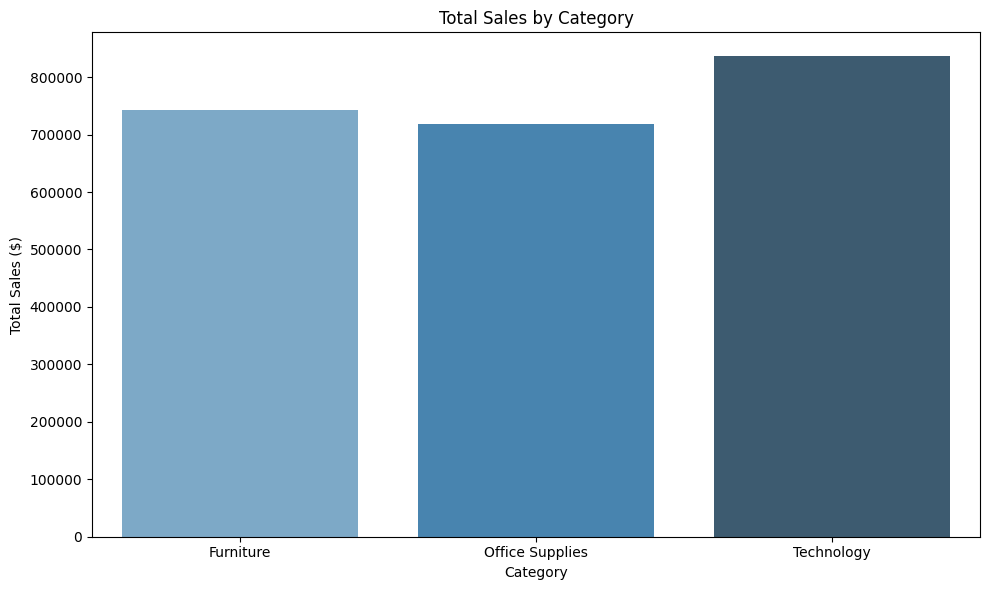

In [19]:
plt.figure(figsize=(10, 6))
category_sales = superstore_df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(x='Category', y='Sales', data=category_sales, palette='Blues_d')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../Visuals/sales_by_category.png')
plt.show()

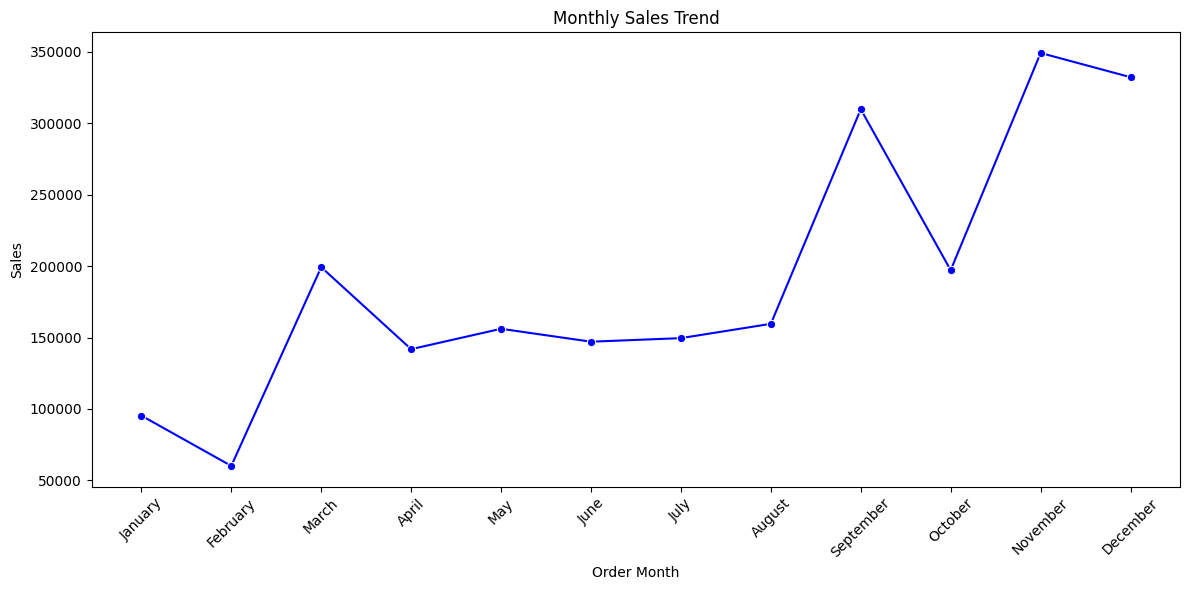

In [20]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = superstore_df.groupby('Order Month')['Sales'].sum()\
    .reindex(month_order).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Order Month', y='Sales', data=monthly_sales, marker='o', color='blue')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../Visuals/monthly_sales_trend.png')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_10804\3874901487.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Profit', data=region_profit, palette='Greens_d')


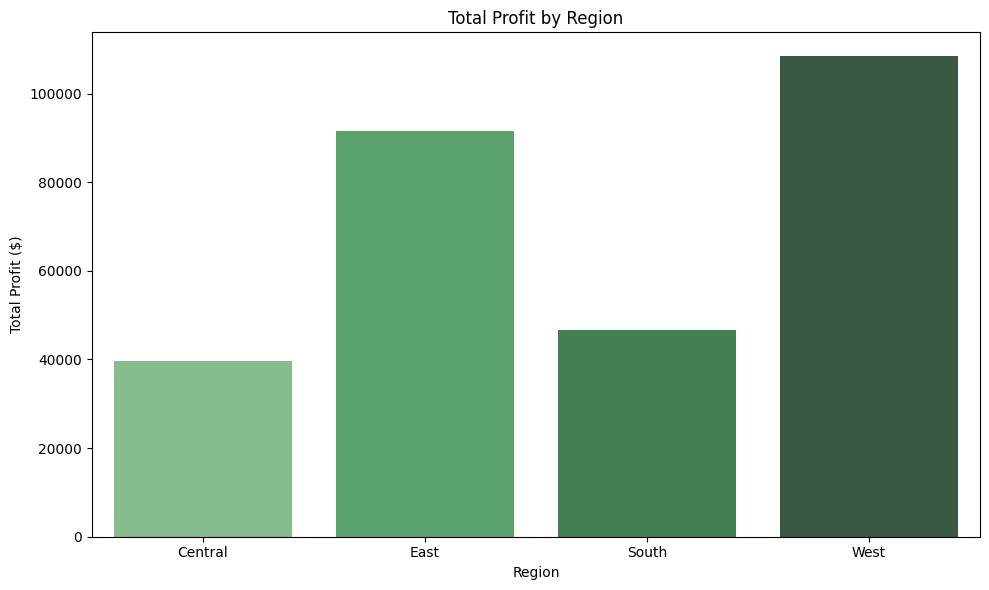

In [21]:
plt.figure(figsize=(10, 6))
region_profit = superstore_df.groupby('Region')['Profit'].sum().reset_index()
sns.barplot(x='Region', y='Profit', data=region_profit, palette='Greens_d')
plt.title('Total Profit by Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('../Visuals/profit_by_region.png')
plt.show()

In [33]:
print("BUSINESS QUESTIONS AND ANSWERS")

BUSINESS QUESTIONS AND ANSWERS


##### Q1

In [30]:
best_category = superstore_df.groupby('Category')['Sales'].sum().idxmax()
print(f"\n1. Highest Sales Category: {best_category}")


1. Highest Sales Category: Technology


##### Q2

In [29]:
best_region = superstore_df.groupby('Region')['Profit'].sum().idxmax()
print(f"2. Most Profitable Region: {best_region}")

2. Most Profitable Region: West


##### Q3

In [28]:
best_month = superstore_df.groupby('Order Month')['Sales'].sum().idxmax()
print(f"3. Best Sales Month: {best_month}")

3. Best Sales Month: November


##### Q4

In [26]:
best_product = superstore_df.groupby('Product Name')['Sales'].sum().idxmax()
print(f"4. Best Performing Product: {best_product}")

4. Best Performing Product: Canon imageCLASS 2200 Advanced Copier


### KPIs

In [25]:
print(f"\nTotal Sales: ${superstore_df['Sales'].sum():,.2f}")
print(f"Total Profit: ${superstore_df['Profit'].sum():,.2f}")
print(f"Profit Margin: {(superstore_df['Profit'].sum()/superstore_df['Sales'].sum()*100):.1f}%")
print(f"Total Orders: {superstore_df['Order ID'].nunique():,}")


Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.5%
Total Orders: 5,009


In [35]:
##### Save cleaned dataset
superstore_df.to_csv('../data/superstore_clean.csv', index=False)
print("Clean dataset saved to Data/superstore_clean.csv!")
print(f"Final dataset shape: {superstore_df.shape}")
print(f"Total columns: {len(superstore_df.columns)}")
print(f"\nColumns in clean dataset:")
for col in superstore_df.columns:
    print(f"  - {col}")

Clean dataset saved to Data/superstore_clean.csv!
Final dataset shape: (9994, 25)
Total columns: 25

Columns in clean dataset:
  - Row ID
  - Order ID
  - Order Date
  - Ship Date
  - Ship Mode
  - Customer ID
  - Customer Name
  - Segment
  - Country
  - City
  - State
  - Postal Code
  - Region
  - Product ID
  - Category
  - Sub-Category
  - Product Name
  - Sales
  - Quantity
  - Discount
  - Profit
  - Order Month
  - Order Year
  - Order Quarter
  - Ship Days
